# Time Resolved Absorption Spectroscopy

## Aim
To examine how fast the excited triplet state 3ZnTPP* state is depopulated after being populated by a pump laser pulse by computing the relaxation time.

##Apparatus
- Pump laser (520 nm) and probe laser (450 nm) with variable delay control
- Photodetector for measuring probe intensity post-sample
- Sample: ZnTPP (0.5 mM in toluene, 1.7 mg in 5 mL)
- Thorlabs TA Experiment software for alignment, data acquisition, and fitting
- Experimental setup including beam overlap in sample volume


## Theory
Transient absorption is defined as the difference in absorbance ΔA between two states of the system: the absorbance of the probe laser by the sample directly following a pump laser and absorbance of the probe laser without a pump laser pulse. The measurements are performed at a fixed probe laser wavelength. The delay between the pump and probe lasers is denoted by $\tau$. By varying the delay $\tau$ between pump and probe laser a TA decay curve is measured and used for evaluation. The absorbance A of light in a substance is given by Lambert-Beer's Law:

$$A = - log(I/I_0) = d \cdot \sum_{(i=1)}^n[\epsilon_i \cdot c_i]$$

where $c_i$ is the concentration and $\epsilon_i$ is molar extinction factor.

In the initial step, the pump laser excites the sample into a triplet state. The decay of a chromophore in the triplet state can be described by the rate equation:

$$\frac{dC_T(t)}{dt} = k_1 C_T(t) + k_2 [C_T(t)]^2 + k_3 C_T(t) C_G(t)$$
Here, $C_T(t)$ represents the concentration of molecules in the excited triplet state at time (t), while $C_G(t)$ denotes the concentration in the ground state. The rate constants $k_1$, $k_2$, and $k_3$ correspond to different deactivation mechanisms.

The first term, $k_1 C_T(t)$, accounts for unimolecular relaxation back to the ground state and is typically the dominant decay pathway. The remaining two terms describe bimolecular deactivation processes: the second term corresponds to triplet-triplet annihilation, while the third term represents quenching of the excited triplet state by ground-state molecules.

In typical experimental conditions, the concentration of excited molecules is significantly lower than that of ground-state molecules. Consequently, the term proportional to $[C_T(t)]^2$ can be neglected. Furthermore, since only a small fraction of molecules are excited, the ground-state concentration can be approximated as constant, i.e., $C_G(t) \approx C_G$.

Under these assumptions, the rate equation simplifies to:

$$\frac{d C_T(t)}{dt} = C_T(t)(k_1 + k_3 C_G)$$
Defining an effective decay constant:

$$k_0 = k_1 + k_3 C_G$$

the equation reduces to a first-order differential equation:
$$\frac{d C_T(t)}{dt} = k_0 C_T(t) $$
The solution to this equation is an exponential decay:
$$ C_T(t) = C_T(0) e^{-k_0 t}$$

This describes the temporal evolution of the triplet state population, with a characteristic decay time given by: $\tau = \frac{1}{k_0}$

Hence $\Delta A$ can be written as -
$$ \Delta A = A_0 e^{-\frac{t}{\tau}}$$

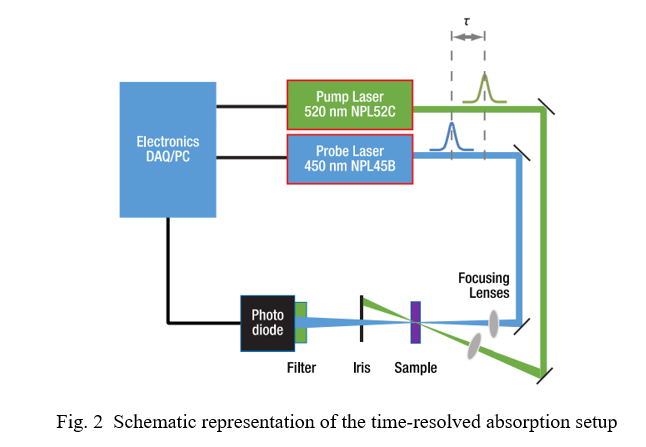

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

df = pd.read_csv('100 MM.csv')

FileNotFoundError: [Errno 2] No such file or directory: '100 MM.csv'

In [ ]:
decay_data = df[df['Laser Delay [ns]'] > 150]
x = decay_data['Laser Delay [ns]'].values
y = decay_data['TA [mOD]'].values

def exp_decay(t, A, tau):
    return A * np.exp(-t / tau)

guess = [max(y), 1000]
popt, pcov = curve_fit(exp_decay, x, y, p0=guess)
A_fit, tau_fit = popt
print(f"Calculated Relaxation Time: {tau_fit:.2f} ns")

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Experimental Data', s=10, alpha=0.8)
plt.plot(x, exp_decay(x, *popt), 'r-', label=f'Fit: τ = {tau_fit:.2f} ns')
plt.title('TA vs Delay Plot')
plt.xlabel('Laser Delay [ns]')
plt.ylabel('TA [mOD]')
plt.legend()
plt.grid(True)
plt.show()

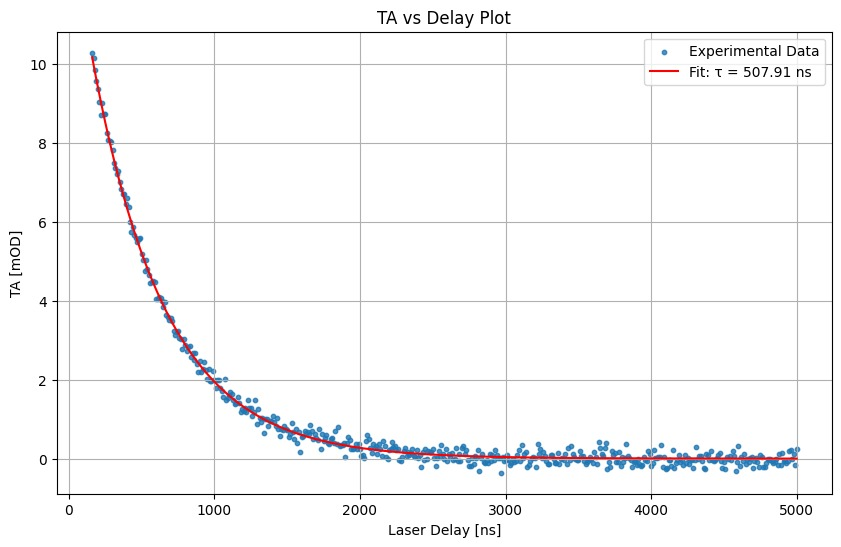

Fitted Parameters:

A =

τ = 507.91 ns

Results:

Relaxation time for pump pulse :

τ = 507.91 ns

##Precautions:


1. DO NOT tamper with laser alignment - contact TA if signal lost
2. Ensure pump-probe beam overlap in sample before starting
3. Wear laser safety goggles (520 nm pump, 450 nm probe)
4. Turn lasers OFF when adjusting optics/sample
5. Do not touch the sample with bare hands - this might introduce some smudges, resulting in incorrect measurements


## Results and Discussion

The transient absorption (TA) measurements for ZnTPP were recorded over a delay range of approximately −400 ns to 5000 ns. The obtained curves exhibit a sharp rise in signal immediately after the pump pulse, followed by a smooth decay over time, consistent with the expected behavior of the excited triplet state $^3\mathrm{ZnTPP}^*$.

Multiple individual traces (5 in total) were recorded under identical experimental conditions. These traces showed minor variations due to experimental noise and fluctuations in laser intensity. To improve accuracy and reduce noise, an averaged transient absorption curve was computed from the individual traces and used for further analysis.

The transient absorbance $\Delta A$ was calculated from the probe intensities with and without the pump pulse. The decay portion of the averaged curve (excluding the initial rise region) was fitted using a single exponential function:

$$
\Delta A(t) = A_0 e^{-t/\tau}
$$

From the exponential fitting of the averaged data, the relaxation time of the excited triplet state was determined to be:

- **Relaxation time:** $\tau \approx 508 \ \text{ns}$

### Discussion

The observed decay follows first-order kinetics, indicating that the depopulation of the excited triplet state is dominated by unimolecular relaxation processes. This is consistent with the theoretical model, where the decay of the excited state is governed by a single effective rate constant.

The use of multiple traces and their averaging significantly improves the reliability of the measurement by reducing random noise and experimental fluctuations. The close agreement between individual traces and the averaged curve confirms the reproducibility of the experiment.

The transient absorption signal is predominantly positive, suggesting that **Excited State Absorption (ESA)** and **Photoproduct Absorption (PA)** are the dominant contributing processes, while **Ground State Bleaching (GSB)** has a comparatively smaller effect.

Any minor deviations from ideal exponential behavior can be attributed to:
- Instrumental noise  
- Laser intensity fluctuations  
- Slight misalignment in pump-probe overlap  
- Possible secondary processes such as weak quenching effects  

Overall, the experiment successfully demonstrates that the excited triplet state $^3\mathrm{ZnTPP}^*$ undergoes exponential decay with a characteristic relaxation time on the order of hundreds of nanoseconds, consistent with typical photophysical behavior of such systems.